In [8]:
using Plots
using Random
using Statistics

In [39]:
mutable struct MonteCarlo
    # scale
    L::Float64          # size

    # physical quantities of molecules
    x                       # position: 0 < x < L
    y                       # position: 0 < y < L
    μ_x                     # direction vector of magnetic moment
    μ_y
    total_energy
    energy_interaction
    interaction_table

    diameter::Float64       # diameter of molecules
    λ::Float64              # dimensionless parameter of molecule-molecule interaction
    ξ::Float64              # dimensionless parameter of molecule-field interaction

    # thermodynamical parameters
    N::Int                  # total number of molecules
    density::Float64        # number density of molecules

    # hyperparameters
    cutoff_radius::Float64      # cutoff radius of molecule-molecule interaction
    max_move                    # maximum movement distance
    max_angle                   # maximum angle change

    function _init_position(scale, L, ϵ=0.001)
        # set molecules as square lattice
        lattice_constant = L / scale

        x = []
        y = []
        for i = 1 : scale, j = 1 : scale
            push!(x, i * lattice_constant + ϵ)
            push!(y, j * lattice_constant + ϵ)
        end
        return x, y
    end

    function _init_direction(N)
        μ_x = []
        μ_y = []
        for _ = 1 : N
            θ = 2.0 * π * rand(Float64)
            push!(μ_x, sin(θ))
            push!(μ_y, cos(θ))
        end

        return μ_x, μ_y
    end

    function _init_energy(N, L, cutoff_radius, λ, ξ, diameter, x, y, μ_x, μ_y)
        total_energy = [-ξ * μ_y[i] for i = 1 : N]
        energy_interaction = zeros(N, N)
        interaction_table = [[] for _ = 1 : N]
        for i = 1 : N
            for j = 1 : N
                if j == i
                    continue
                end

                Δx = x[j] - x[i]
                Δy = y[j] - y[i]
                # boundary condition
                if Δx >= L * 0.5
                    Δx -= L
                elseif Δx < -L * 0.5
                    Δx += L
                end
                if Δy >= L * 0.5
                    Δy -= L
                elseif Δy < -L * 0.5
                    Δy += L
                end

                r = sqrt(Δx ^ 2 + Δy ^ 2)
                if (r < diameter) || (r > cutoff_radius)
                    continue
                end

                # magnetic dipole interaction energy between molecules
                E_interaction = λ / (r ^ 3) * (μ_x[i] * μ_x[j] + μ_y[i] * μ_y[j] - 3.0 / (r ^ 2) * (μ_x[i] * Δx + μ_y[i] * Δy) * (μ_x[j] * Δx + μ_y[j] * Δy))
                total_energy[i] += E_interaction
                push!(interaction_table[i], j)
                energy_interaction[j, i] = E_interaction
            end
        end
        return total_energy, energy_interaction, interaction_table
    end

    function MonteCarlo(N, density, λ, ξ; diameter=1.0, cutoff_radius=8.0, max_move=0.5, max_angle=π/18.0)
        scale = Int(round(sqrt(N)))
        N_squared = scale ^ 2
        L = sqrt(N_squared / density)
        if L < 2.0 * cutoff_radius
            error("density is too small")
        end

        x, y = _init_position(scale, L)
        μ_x, μ_y = _init_direction(N_squared)
        total_energy, energy_interaction, interaction_table = _init_energy(N_squared, L, cutoff_radius, λ, ξ, diameter, x, y, μ_x, μ_y)

        new(L, x, y, μ_x, μ_y, total_energy, energy_interaction, interaction_table, diameter, λ, ξ, N_squared, density, cutoff_radius, max_move, max_angle)
    end
end

function show_parameters(mc)
    println("size: $(mc.L)")
    println("molecular diameter: $(mc.diameter), # of molecules: $(mc.N), density: $(mc.density)")
    println("interaction parameter: lambda = $(mc.λ), xi = $(mc.ξ)")
    println("hyper parameters")
    println("cutoff radius: $(mc.cutoff_radius), maximal move distance per one iteration: $(mc.max_move), maximal move angle per one iteration: $(mc.max_angle)")
end

function solve!(mc, max_iter)
    show_parameters(mc)

    magnetic_moment_direction_x = []
    magnetic_moment_direction_y = []
    mean_energy = []
    for _ = 1 : max_iter
        metropolis!(mc)
        record_data!(mc, magnetic_moment_direction_x, magnetic_moment_direction_y, mean_energy)
    end

    plot_molecules(mc)
    return mean_energy
end

function metropolis!(mc)
    for i = 1 : mc.N
        x_candidate, y_candidate = _position_candidate(mc, i)
        μ_x_candidate, μ_y_candidate = _direction_candidate(mc, i)
        is_overlapped, interaction_table_candidate, energy_candidate, total_energy_candidate = _energy_candidate(mc, i, x_candidate, y_candidate, μ_x_candidate, μ_y_candidate)
        if is_overlapped
            continue
        end

        # metropolis step
        ΔE = total_energy_candidate - mc.total_energy[i]
        if rand(Float64) >= exp(-ΔE)
            continue
        end

        # accept case
        mc.x[i] = x_candidate
        mc.y[i] = y_candidate
        mc.μ_x[i] = μ_x_candidate
        mc.μ_y[i] = μ_y_candidate
        mc.total_energy[i] = total_energy_candidate

        _interaction_term_update!(mc, i, interaction_table_candidate, energy_candidate)
    end
end

function _position_candidate(mc, i)
    x_candidate = mc.x[i] + mc.max_move * (1.0 - 2.0 * rand(Float64))
    y_candidate = mc.y[i] + mc.max_move * (1.0 - 2.0 * rand(Float64))
    # boundary condition
    if x_candidate >= mc.L
        x_candidate -= mc.L
    elseif x_candidate < 0.0
        x_candidate += mc.L
    end
    if y_candidate >= mc.L
        y_candidate -= mc.L
    elseif y_candidate < 0.0
        y_candidate += mc.L
    end
    return x_candidate, y_candidate
end

function _direction_candidate(mc, i)
    angle = mc.max_angle * (1.0 - 2.0 * rand(Float64))
    μ_x_candidate = cos(angle) * mc.μ_x[i] - sin(angle) * mc.μ_y[i]
    μ_y_candidate = sin(angle) * mc.μ_x[i] + cos(angle) * mc.μ_y[i]
    μ = sqrt(μ_x_candidate ^ 2 + μ_y_candidate ^ 2)
    μ_x_candidate /= μ
    μ_y_candidate /= μ

    return μ_x_candidate, μ_y_candidate
end

function _energy_candidate(mc, i, x_candidate, y_candidate, μ_x_candidate, μ_y_candidate)
    interaction_table_candidate = []
    energy_candidate = []
    total_energy_candidate = 0.0
    for j = 1 : mc.N
        if j == i
            continue
        end

        Δx = mc.x[j] - x_candidate
        Δy = mc.y[j] - y_candidate
        # boundary condition
        if Δx >= mc.L * 0.5
            Δx -= mc.L
        elseif Δx < -mc.L * 0.5
            Δx += mc.L
        end
        if Δy >= mc.L * 0.5
            Δy -= mc.L
        elseif Δy < -mc.L * 0.5
            Δy += mc.L
        end

        r = sqrt(Δx ^ 2 + Δy ^ 2)
        if r < mc.diameter              # molecules overlapped -> reject
            return (true, interaction_table_candidate, energy_candidate, 0.0)
        elseif r > mc.cutoff_radius
            continue
        end

        # magnetic dipole interaction energy between molecules
        E_mm = mc.λ / (r ^ 3) * (μ_x_candidate * mc.μ_x[j] + μ_y_candidate * mc.μ_y[j] - 3.0 * (μ_x_candidate * Δx + μ_y_candidate * Δy) * (mc.μ_x[j] * Δx + mc.μ_y[j] * Δy) / (r ^ 2))
        push!(interaction_table_candidate, j)
        push!(energy_candidate, E_mm)
        total_energy_candidate += E_mm
    end
    # interaction with magnetic field
    total_energy_candidate -= mc.ξ * μ_y_candidate

    return (false, interaction_table_candidate, energy_candidate, total_energy_candidate)
end

function _interaction_term_update!(mc, i, interaction_table_candidate, energy_candidate)
    # add i-j interaction data
    for (index, j) ∈ enumerate(interaction_table_candidate)
        if i ∈ mc.interaction_table[j]
            mc.total_energy[j] += energy_candidate[index] - mc.energy_interaction[i, j]
            mc.energy_interaction[i, j] = energy_candidate[index]
        else
            push!(mc.interaction_table[j], i)
            mc.total_energy[j] += energy_candidate[index]
            mc.energy_interaction[i, j] = energy_candidate[index]
        end
    end

    # elase out of interaction-range data
    out_of_range_molecules = setdiff(mc.interaction_table[i], interaction_table_candidate)
    for mol ∈ out_of_range_molecules
        mc.total_energy[mol] -= mc.energy_interaction[i, mol]
        mc.interaction_table[mol] = setdiff(mc.interaction_table[mol], [i])
    end

    # update i data
    mc.interaction_table[i] = interaction_table_candidate
    for (index, j) ∈ enumerate(interaction_table_candidate)
        mc.energy_interaction[j, i] = energy_candidate[index]
    end
end

function record_data!(mc, magnetic_moment_direction_x, magnetic_moment_direction_y, mean_energy)
    _magnetic_moment_direction_x = mean(mc.μ_x)
    _magnetic_moment_direction_y = mean(mc.μ_y)
    _mean_energy = 0.5 *  (mean(mc.total_energy) - mc.ξ * _magnetic_moment_direction_y)

    push!(magnetic_moment_direction_x, _magnetic_moment_direction_x)
    push!(magnetic_moment_direction_y, _magnetic_moment_direction_y)
    push!(mean_energy, _mean_energy)
end

function plot_molecules(mc)
    quiver(mc.x, mc.y, quiver=(mc.μ_x, mc.μ_y))
    scatter!(mc.x, mc.y, label="molecule")
end

plot_molecules (generic function with 1 method)

In [41]:
N = 64
density = 0.1
lambda = 4.0
xi = 10.0

mc = MonteCarlo(N, density, lambda, xi)
show_parameters(mc)

size: 25.298221281347036
molecular diameter: 1.0, # of molecules: 64, density: 0.1
interaction parameter: lambda = 4.0, xi = 10.0
hyper parameters
cutoff radius: 8.0, maximal move distance per one iteration: 0.5, maximal move angle per one iteration: 0.17453292519943295


In [ ]:
solve!(mc, 50000)

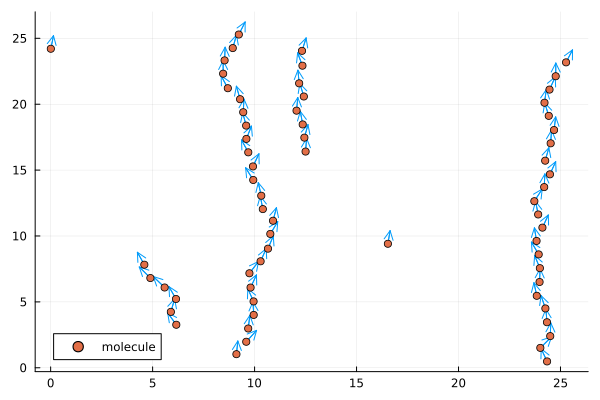

In [32]:
plot_molecules(mc)